# Telco Customer Churn — Modelling
**Goal:** Build, evaluate, and compare churn prediction models.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
print('Libraries loaded.')

Libraries loaded.


## 1. Load and Prepare Data

In [2]:
# Load and clean
df = pd.read_csv('../data/WA_Fn-UseC_-Telco-Customer-Churn.csv')
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df = df[df['TotalCharges'].notnull()].reset_index(drop=True)
df.drop(columns=['customerID'], inplace=True)
df['SeniorCitizen'] = df['SeniorCitizen'].map({0: 'No', 1: 'Yes'})

# Encode
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
target_col = 'Churn'
categorical_cols = [col for col in df.columns if col not in numerical_cols + [target_col]]
binary_cols = [col for col in categorical_cols if df[col].nunique() == 2]
multi_cols = [col for col in categorical_cols if df[col].nunique() > 2]

le = LabelEncoder()
df_encoded = df.copy()
for col in binary_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col])
df_encoded['Churn'] = le.fit_transform(df_encoded['Churn'])
df_encoded = pd.get_dummies(df_encoded, columns=multi_cols, drop_first=True)

# Split
X = df_encoded.drop(columns=['Churn'])
y = df_encoded['Churn']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale
scaler = StandardScaler()
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

print('Data ready.')
print('Training set:', X_train.shape)
print('Test set:', X_test.shape)

Data ready.
Training set: (5625, 30)
Test set: (1407, 30)


## 2. Model 1 — Logistic Regression (Baseline)

In [3]:
lr = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)[:, 1]

print('=== LOGISTIC REGRESSION ===')
print(classification_report(y_test, y_pred_lr, target_names=['No Churn', 'Churn']))
print(f'ROC-AUC Score: {roc_auc_score(y_test, y_prob_lr):.4f}')

=== LOGISTIC REGRESSION ===
              precision    recall  f1-score   support

    No Churn       0.90      0.70      0.79      1033
       Churn       0.49      0.79      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.79      0.73      0.74      1407

ROC-AUC Score: 0.8353


## 3. Model 2 — Random Forest

In [4]:
rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

print('=== RANDOM FOREST ===')
print(classification_report(y_test, y_pred_rf, target_names=['No Churn', 'Churn']))
print(f'ROC-AUC Score: {roc_auc_score(y_test, y_prob_rf):.4f}')

=== RANDOM FOREST ===
              precision    recall  f1-score   support

    No Churn       0.83      0.90      0.86      1033
       Churn       0.63      0.49      0.55       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.71      1407
weighted avg       0.78      0.79      0.78      1407

ROC-AUC Score: 0.8186


## 4. Confusion Matrices

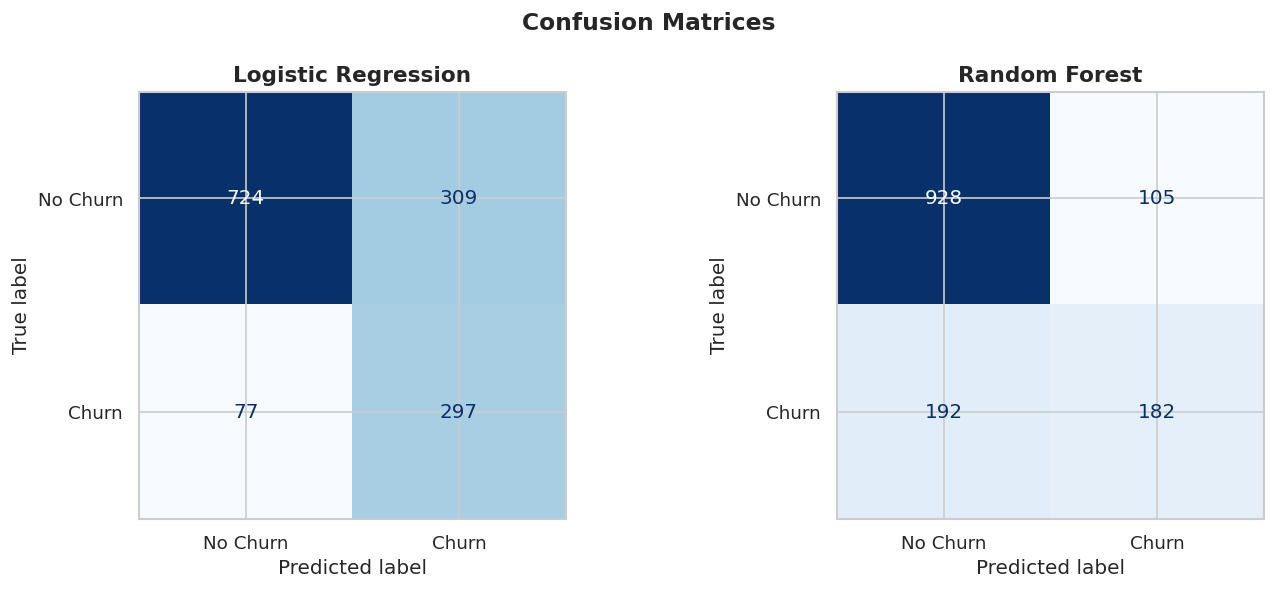

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, y_pred, title in zip(
    axes,
    [y_pred_lr, y_pred_rf],
    ['Logistic Regression', 'Random Forest']
):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Churn', 'Churn'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(title, fontsize=13, fontweight='bold')

plt.suptitle('Confusion Matrices', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/07_confusion_matrices.png', bbox_inches='tight')
plt.show()

## 5. ROC Curves

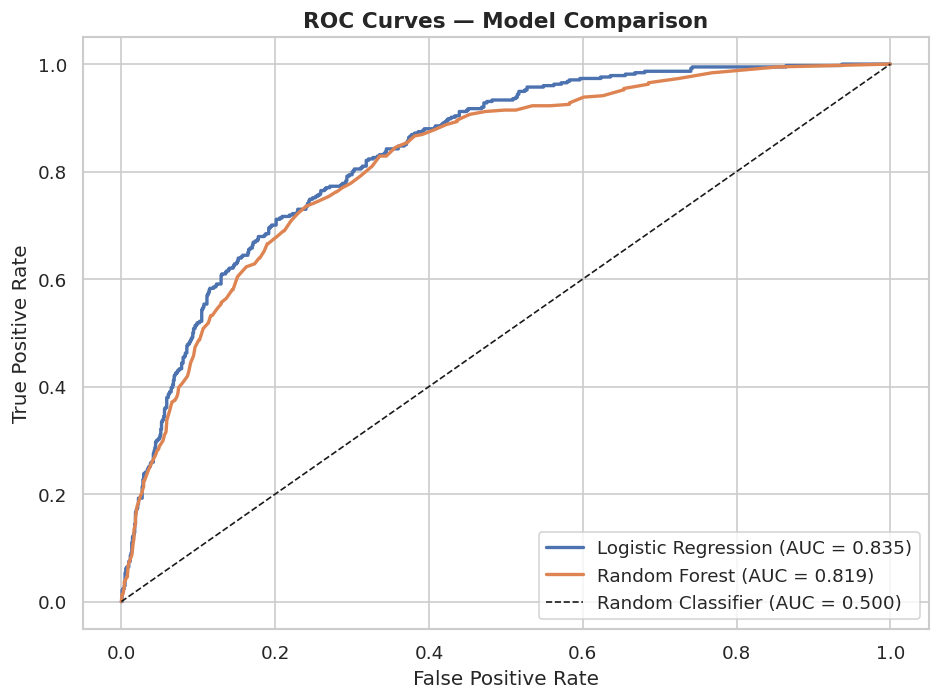

In [6]:
plt.figure(figsize=(8, 6))

for y_prob, label, color in [
    (y_prob_lr, 'Logistic Regression', '#4C72B0'),
    (y_prob_rf, 'Random Forest', '#DD8452')
]:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f'{label} (AUC = {auc:.3f})', color=color, lw=2)

plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier (AUC = 0.500)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — Model Comparison', fontsize=13, fontweight='bold')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('../outputs/figures/08_roc_curves.png', bbox_inches='tight')
plt.show()

## 6. Feature Importance (Random Forest)

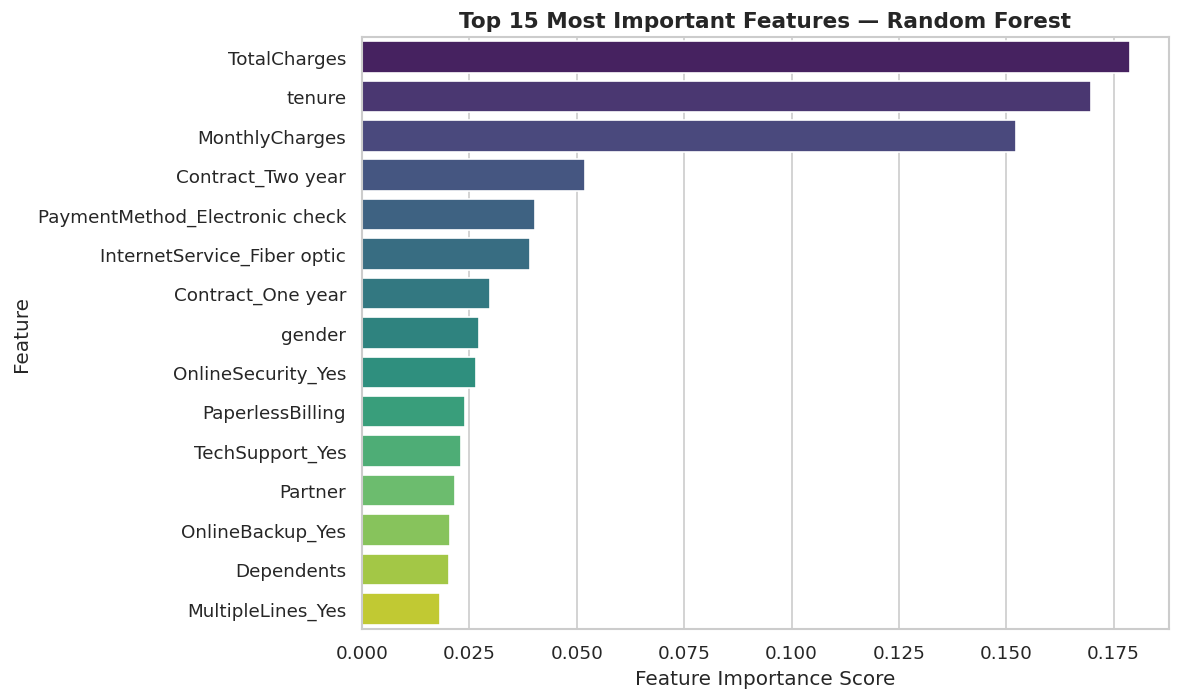

Top 10 features:
                       Feature  Importance
                  TotalCharges    0.178893
                        tenure    0.169656
                MonthlyCharges    0.152241
             Contract_Two year    0.051952
PaymentMethod_Electronic check    0.040303
   InternetService_Fiber optic    0.039097
             Contract_One year    0.029686
                        gender    0.027180
            OnlineSecurity_Yes    0.026506
              PaperlessBilling    0.024056


In [7]:
importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df, x='Importance', y='Feature', palette='viridis')
plt.title('Top 15 Most Important Features — Random Forest', fontsize=13, fontweight='bold')
plt.xlabel('Feature Importance Score')
plt.tight_layout()
plt.savefig('../outputs/figures/09_feature_importance.png', bbox_inches='tight')
plt.show()

print('Top 10 features:')
print(importance_df.head(10).to_string(index=False))

## 7. Model Comparison Summary

In [8]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf)
    ],
    'Precision': [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_rf)
    ],
    'Recall': [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_rf)
    ],
    'F1 Score': [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_rf)
    ],
    'ROC-AUC': [
        roc_auc_score(y_test, y_prob_lr),
        roc_auc_score(y_test, y_prob_rf)
    ]
}).round(4)

print('=== MODEL COMPARISON ===')
print(results.to_string(index=False))

=== MODEL COMPARISON ===
              Model  Accuracy  Precision  Recall  F1 Score  ROC-AUC
Logistic Regression    0.7257     0.4901  0.7941    0.6061   0.8353
      Random Forest    0.7889     0.6341  0.4866    0.5507   0.8186


## 8. Save the Best Model

In [9]:
import pickle
import os

os.makedirs('../outputs/models', exist_ok=True)

with open('../outputs/models/random_forest_model.pkl', 'wb') as f:
    pickle.dump(rf, f)

with open('../outputs/models/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print('Model and scaler saved to outputs/models/')
print('Ready for the Streamlit dashboard.')

Model and scaler saved to outputs/models/
Ready for the Streamlit dashboard.
